<!-- #region -->
# Telco Customer Churn - Classification
<!-- #endregion -->

<!-- #region -->
## 1. Business Problem

The goal of this project is to build a binary classification model that predicts whether a telecom customer is likely to churn based on their demographic, service, and account information.

The model will be evaluated using multiple classification metrics, and the final results will be translated into practical recommendations for customer retention.


<!-- #endregion -->

In [19]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv


<!-- #region -->
## 2. Dataset Understanding
<!-- #endregion -->

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Telco-Customer-Churn.csv")
df["TotalCharges"].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

### Initial Dataset Observations

- The dataset contains 7,043 customer records and 21 columns.
- `Churn` is the target variable, leaving 20 potential input features.
- There are no standard null values reported by `df.info()`.
- Most columns are categorical and are currently represented as `object`.
- `SeniorCitizen` and `tenure` are stored as integers, while `MonthlyCharges` is stored as a float.
- `TotalCharges` is stored as an `object` despite representing a monetary value, so this requires further investigation.

<!-- #region -->
## 3. Data Quality Assessment
<!-- #endregion -->

In [21]:
# A. Missing values
print(df.isnull().sum())

# B. Duplicates
print(df.duplicated().sum())

# C. Inconsistent data types
# For categorical columns, investigate what values actually exist.
# TotalCharges → object
print(df["TotalCharges"].unique()[:20])

# D. Inconsistent values
# For categorical columns, investigate what values actually exist.

# E. Numerical ranges / unusual values
print(df.describe())
# tenure
# MonthlyCharges
# SeniorCitizen

# F. Potentially unnecessary columns
# customerID


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
0
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000   

### Data Quality Assessment

- No standard missing values were found across the dataset.
- No duplicate rows were identified.
- `TotalCharges` is stored as an `object` data type even though it represents a numerical monetary value.
- The values inspected in `TotalCharges` appear to be numeric values stored as strings.
- `tenure` ranges from 0 to 72 months, which is reasonable for a customer tenure variable.
- `MonthlyCharges` contains positive numerical values with no immediately obvious invalid values.
- `SeniorCitizen` is stored as an integer but represents a binary category (0/1).

## 4. Data Cleaning

In [22]:

# Step 1: Turn blank strings into missing values
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Step 2: Convert the column to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df["TotalCharges"].dtype

# Step 3: Check the missing values again
df["TotalCharges"].isnull().sum()
df[df["TotalCharges"].isnull()]

#If a customer's tenure is 0 months, what would you expect their total charges to be?
df[df["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

# df.info()
# df.isnull().sum()
# df.head()
df[df["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]
# Check for missing values
df.isnull().sum()

# Check for duplicates
df.duplicated().sum()

# Check data types
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


TotalCharges: The column was initially stored as an object because 11 records contained blank values. After converting the column to numeric, these blanks became missing values. All 11 affected customers had a tenure of 0, indicating newly joined customers with no accumulated charges. Rather than removing these observations, I replaced the missing values with 0, which is consistent with their tenure and preserves the records.

<!-- #region -->
## 5. Exploratory Data Analysis
<!-- #endregion -->

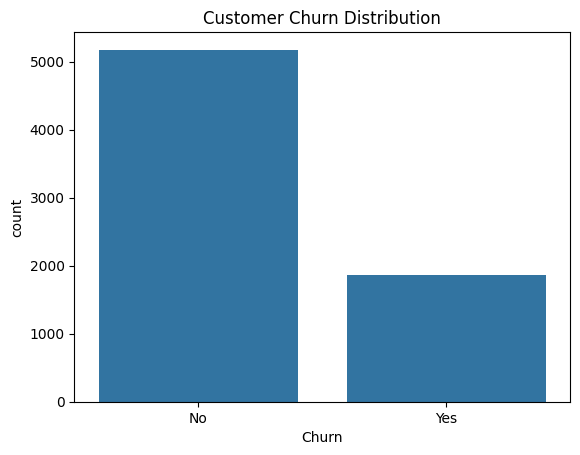

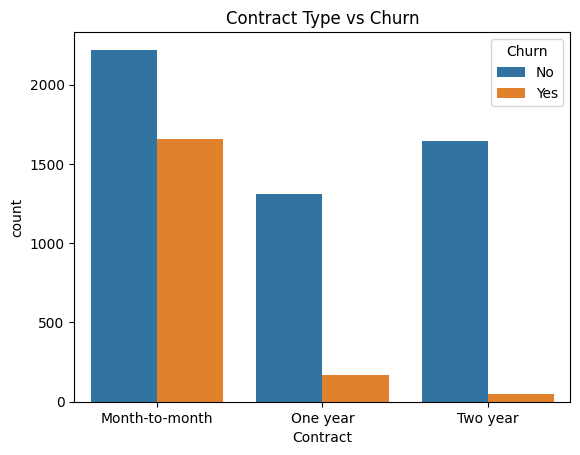

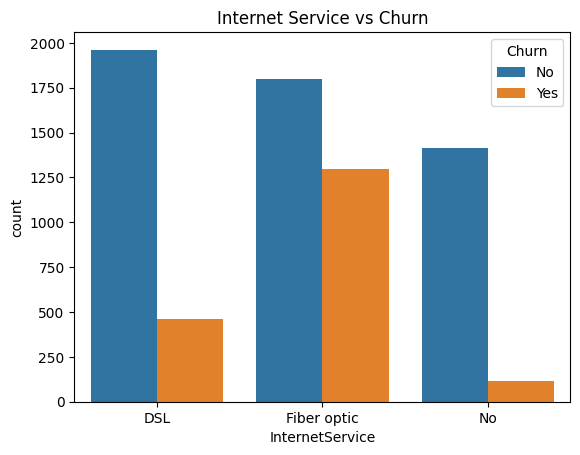

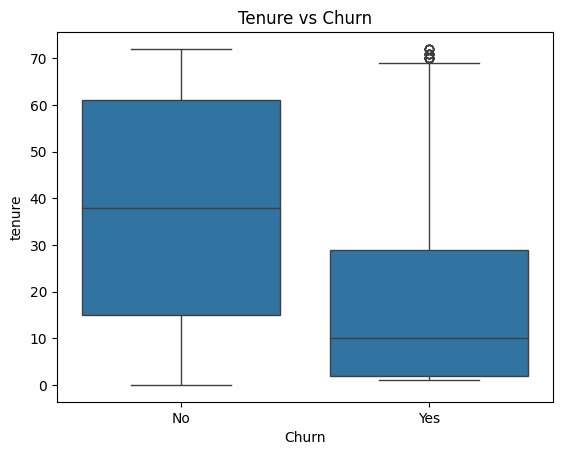

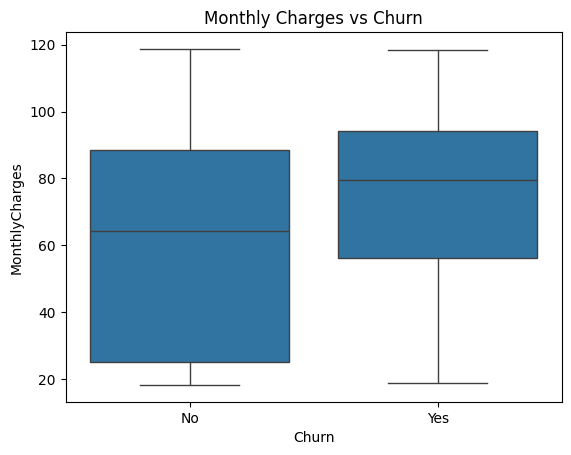

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()
df["Churn"].value_counts()


sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.show()

sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Service vs Churn")
plt.show()

sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

1. Churn distribution:
The dataset is imbalanced, with approximately 73.5% of customers not churning and 26.5% churning. This indicates that churn is the minority class, so accuracy alone may not be sufficient for evaluating the models. Metrics such as precision, recall, F1-score, and ROC-AUC will therefore be considered.

2. Contract vs Churn:
Contract type shows a strong relationship with churn. Month-to-month customers have substantially higher churn rates than customers on one- or two-year contracts. This suggests that customers with longer-term contracts may be more likely to remain with the company. Contract type may therefore be an important predictive feature for the classification model.

3. Internet Service vs Churn:
Internet service type appears to be associated with customer churn. Fiber optic customers show a noticeably higher churn rate than DSL customers, while customers without internet service have the lowest churn rate. This relationship may reflect differences in pricing, service experience, or customer expectations and makes InternetService a potentially useful predictive feature.

4. Tenure vs Churn:
Customers who churn tend to have shorter tenure than customers who remain with the company. The distribution suggests that newer customers are generally at greater risk of churn, while customers with longer relationships tend to be more likely to remain. Tenure is therefore likely to be an important predictive feature.

5. Monthly Charges vs Churn:
Customers who churn tend to have higher monthly charges compared with customers who remain. This suggests that monthly pricing or the services associated with higher charges may be related to churn. MonthlyCharges may therefore provide useful predictive information for the model.

<!-- #region -->
## 6. Feature Engineering
<!-- #endregion -->

Feature 1: IsNewCustomer

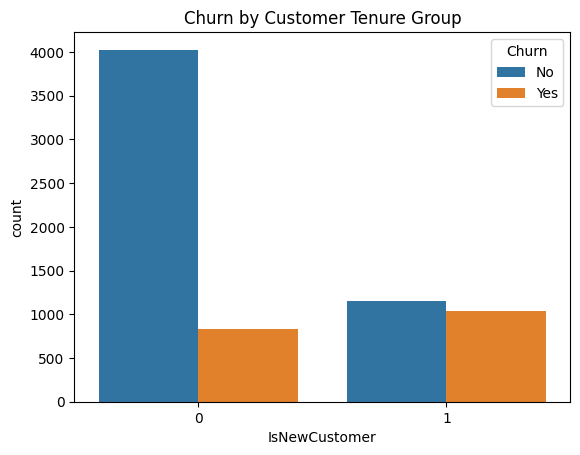

In [24]:
# df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

df["IsNewCustomer"] = (df["tenure"] <= 12).astype(int)

# df[["tenure", "IsNewCustomer"]].head(10)

pd.crosstab(
    df["IsNewCustomer"],
    df["Churn"],
    normalize="index"
) * 100

sns.countplot(
    data=df,
    x="IsNewCustomer",
    hue="Churn"
)
plt.title("Churn by Customer Tenure Group")
plt.show()


Customers with tenure ≤ 12 months were classified as new customers. This feature was created because EDA suggested that customers with shorter tenure churn more frequently.

Feature 2: HasFamily

In [25]:
df["HasFamily"] = (
    (df["Partner"] == "Yes") |
    (df["Dependents"] == "Yes")
).astype(int)

pd.crosstab(
    df["HasFamily"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
HasFamily,,
0,65.762195,34.237805
1,80.175392,19.824608


Customers without a partner or dependents had a churn rate of 34.2%, compared with 19.8% among customers with a partner or dependents. This suggests that customers with family connections may be more likely to remain with the company. Therefore, HasFamily was retained as an engineered feature for model training.

Feature 3: TotalServices

In [26]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]


df["TotalServices"] = (df[service_columns] == "Yes").sum(axis=1)
df["TotalServices"].value_counts().sort_index()
pd.crosstab(
    df["TotalServices"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TotalServices,,
0,56.250000,43.750000
1,78.894768,21.105232
2,67.171717,32.828283
3,63.523316,36.476684
4,68.655098,31.344902
5,74.449339,25.550661
6,77.514793,22.485207
7,87.594937,12.405063
8,94.711538,5.288462


TotalServices was created to represent the number of subscribed services for each customer. The feature was designed to capture the level of customer engagement and product adoption. The analysis showed a general tendency for customers with more subscribed services to have lower churn rates. Customers with all eight counted services had a churn rate of 5.3%, compared with 43.8% for customers with no counted services. Although the relationship is not perfectly linear, the difference suggests that service adoption may contain useful information for predicting churn. Therefore, the feature was retained for model training.

<!-- #region -->
## 7. Data Preparation
<!-- #endregion -->

In [27]:
# Handle missing TotalCharges
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Separate features and target
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Identify feature types
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns


# Create the preprocessing transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit preprocessing on training data
preprocessor.fit(X_train)

# Transform train and test data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape

y_train.value_counts(), y_test.value_counts()

(Churn
 No     4139
 Yes    1495
 Name: count, dtype: int64,
 Churn
 No     1035
 Yes     374
 Name: count, dtype: int64)

Preprocessing: Numerical features were scaled, while categorical features were one-hot encoded. Preprocessing was fitted only on the training data to prevent data leakage.

<!-- #region -->
## 8. Model Training
<!-- #endregion -->

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(
    X_train_processed,
    y_train
)


# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

Two classification models were trained using the preprocessed training data. Logistic Regression provides an interpretable baseline, while Random Forest provides a non-linear model for comparison.

<!-- #region -->
## 9. Model Evaluation
<!-- #endregion -->

In [29]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# LOGISTIC REGRESSION EVALUATION
# ============================================================

# Make predictions
logistic_pred = logistic_model.predict(X_test_processed)

# Get probability predictions
logistic_pred_proba = logistic_model.predict_proba(X_test_processed)


# Confusion Matrix
logistic_cm = confusion_matrix(
    y_test,
    logistic_pred
)


# Evaluation metrics
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    pos_label="Yes"
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    pos_label="Yes"
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    pos_label="Yes"
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_pred_proba[:, 1]
)


# Print Logistic Regression results
print("Logistic Regression")
print("-------------------")
print("Confusion Matrix:")
print(logistic_cm)
print()
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1:", logistic_f1)
print("ROC-AUC:", logistic_roc_auc)


# ============================================================
# RANDOM FOREST EVALUATION
# ============================================================

# Make predictions
rf_pred = rf_model.predict(X_test_processed)

# Get probability predictions
rf_pred_proba = rf_model.predict_proba(X_test_processed)


# Confusion Matrix
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)


# Evaluation metrics
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    pos_label="Yes"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    pos_label="Yes"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    pos_label="Yes"
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_pred_proba[:, 1]
)


# Print Random Forest results
print("\nRandom Forest")
print("-------------")
print("Confusion Matrix:")
print(rf_cm)
print()
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("ROC-AUC:", rf_roc_auc)


# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1": [
        logistic_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ]
})

comparison

Logistic Regression
-------------------
Confusion Matrix:
[[932 103]
 [176 198]]

Accuracy: 0.8019872249822569
Precision: 0.6578073089700996
Recall: 0.5294117647058824
F1: 0.5866666666666667
ROC-AUC: 0.8415898111550286

Random Forest
-------------
Confusion Matrix:
[[916 119]
 [199 175]]

Accuracy: 0.7743080198722498
Precision: 0.5952380952380952
Recall: 0.4679144385026738
F1: 0.5239520958083832
ROC-AUC: 0.8188883722131803


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.801987,0.657807,0.529412,0.586667,0.841590
1,Random Forest,0.774308,0.595238,0.467914,0.523952,0.818888


The trained models were evaluated on the unseen test set using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices. Multiple metrics were used because the dataset contains class imbalance.

Logistic Regression performed better than Random Forest across all evaluated metrics, achieving an ROC-AUC of 0.842 compared with 0.819 for Random Forest. Logistic Regression was therefore selected as the final model for interpretation.

<!-- #region -->
## 10. Model Interpretation
<!-- #endregion -->

In [30]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_model.coef_[0]

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute coefficient value
feature_importance["AbsoluteCoefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,AbsoluteCoefficient
41,cat__Contract_Two year,-0.842854,0.842854
1,num__tenure,-0.791602,0.791602
18,cat__InternetService_DSL,-0.686715,0.686715
19,cat__InternetService_Fiber optic,0.650250,0.650250
39,cat__Contract_Month-to-month,0.627260,0.627260
2,num__MonthlyCharges,-0.576271,0.576271
42,cat__PaperlessBilling_No,-0.340469,0.340469
3,num__TotalCharges,0.272887,0.272887
20,cat__InternetService_No,-0.269237,0.269237
22,cat__OnlineSecurity_No internet service,-0.269237,0.269237


The coefficients of the selected Logistic Regression model were examined to identify which features had the strongest positive or negative association with predicted churn.

<!-- #region -->
## 11. Business Recommendations
<!-- #endregion -->

**Short note**

Business Recommendations: The EDA and model results suggest several customer groups that may benefit from targeted retention strategies. These recommendations are based on observed associations in the dataset and should be validated through business experiments.

**Recommendations**

Target new customers early
Customers with shorter tenure showed substantially higher churn. The company could introduce stronger onboarding, early engagement campaigns, and check-ins during the first year.
Encourage longer-term contracts
Month-to-month customers had considerably higher churn than customers on longer contracts. Offering appropriate incentives for one- or two-year contracts could improve retention.
Investigate high monthly charges
Churners tended to have higher monthly charges. The company should investigate pricing, perceived value, and whether targeted discounts or better service bundles could reduce churn.
Increase service adoption
Customers with more subscribed services generally showed lower churn. Bundling relevant services and encouraging adoption could increase customer engagement and retention.
Use the model to prioritize retention efforts
Instead of contacting every customer, the company can use churn predictions to identify higher-risk customers and focus retention resources where they are most likely to have an impact.

<!-- #region -->
## 12. Conclusion
<!-- #endregion -->

This project developed a binary classification pipeline to predict customer churn using the Telco Customer Churn dataset. After cleaning the data, performing exploratory analysis, engineering relevant features, and applying appropriate preprocessing, Logistic Regression and Random Forest were trained and evaluated. Logistic Regression performed better across all selected metrics, achieving 80.2% accuracy and an ROC-AUC of 0.842. The results highlight factors such as tenure, contract type, monthly charges, and service adoption as useful signals for identifying customers at higher risk of churn. The model can therefore support targeted customer-retention strategies, although further validation and tuning would be required before deployment.